In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import matplotlib.pyplot as plt

2026-04-08 23:01:09.083046: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
model = load_model('model.h5', compile=False)

In [4]:
class_names = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


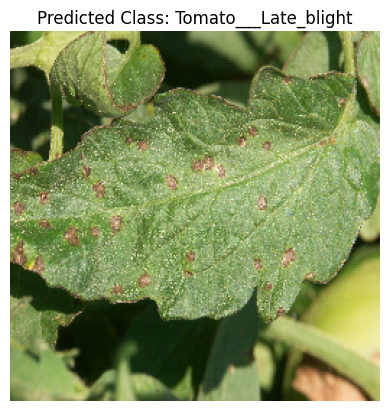

In [5]:
img_path = 'early-blight-of-tomatoOLINEPIC.jpg'
img = tf.keras.utils.load_img(img_path, target_size=(256, 256)) # Loads and resizes
img_array = tf.keras.utils.img_to_array(img)                  # Converts to numpy array
img_array = img_array / 255.0                                 # Normalize
img_array = np.expand_dims(img_array, axis=0)                 # Create batch (1, 256, 256, 3)

# 3. Predict
predictions = model.predict(img_array)
class_idx = np.argmax(predictions[0])

# 4. Show it
plt.imshow(img)
plt.title(f"Predicted Class: {class_names[class_idx]}")
plt.axis('off')
plt.show()